# Validation and Training on CHANDON-3 WELL

In [ ]:
df.head()

,DEPTH,Lithology,NPHI,RHO8,Sv,Phyd,Actual_PP,GR,RT,PP_ratio,GR_roll,NPHI_roll,RHO8_roll,RT_roll
2,2117.4456,claystone,0.482224,2.254642,42.466001,20.771368,25.257119,20.134707,0.159407,1.215958,20.278055,0.482299,2.254476,0.158605
3,2117.5980,claystone,0.481958,2.257879,42.469334,20.772863,25.248258,20.969029,0.156820,1.215444,21.034130,0.482033,2.258142,0.156613
4,2117.7504,claystone,0.481767,2.261477,42.472725,20.774358,25.242090,21.883680,0.154014,1.215060,21.831486,0.481842,2.262061,0.154303
5,2117.9028,claystone,0.481651,2.265601,42.476177,20.775853,25.238600,22.735744,0.151573,1.214804,22.589338,0.481726,2.266524,0.151989
6,2118.0552,claystone,0.481611,2.270707,42.479634,20.777348,25.237805,23.434269,0.149702,1.214679,23.242978,0.481703,2.271917,0.149891


In [ ]:
df.columns

Index(['DEPTH', 'Lithology', 'NPHI', 'RHO8', 'Sv', 'Phyd', 'Actual_PP', 'GR',
       'RT', 'PP_ratio', 'GR_roll', 'NPHI_roll', 'RHO8_roll', 'RT_roll'],
      dtype='object')

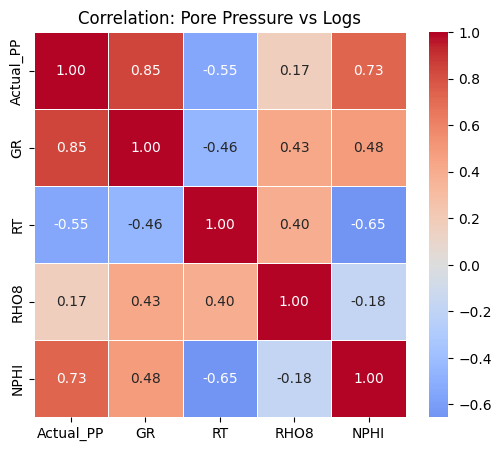

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# SELECT VARIABLES
# =========================
cols = [
    "Actual_PP",
    "GR",
    "RT",
    "RHO8",
    "NPHI"
]

df_corr = df[cols].copy()

# =========================
# CORRELATION MATRIX
# =========================
corr = df_corr.corr()

# =========================
# PLOT HEATMAP
# =========================
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation: Pore Pressure vs Logs")
plt.show()

In [ ]:
!pip install catboost


VALIDATION PERFORMANCE
R2   : 0.9365
MAE  : 0.32
RMSE : 0.41


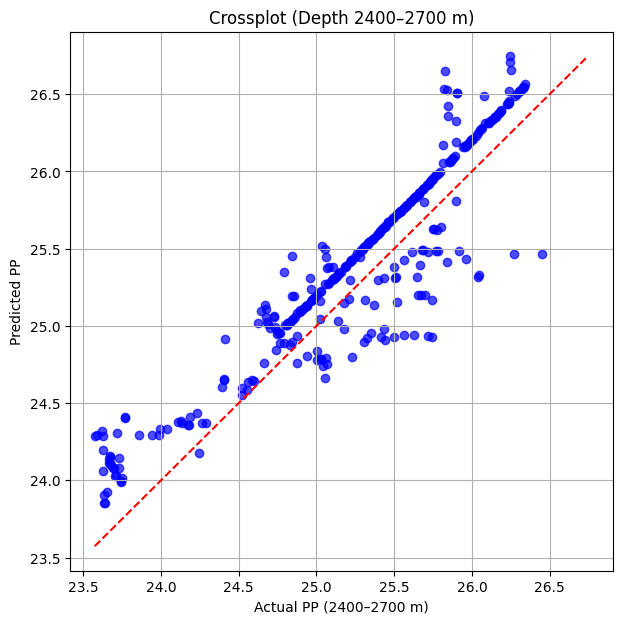

In [ ]:
# =========================================================
# RANDOM TRAIN / VALIDATION ON TEST_updated.csv
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from catboost import CatBoostRegressor

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv("/content/TEST_updated.csv")

# =========================================================
# DEPTH FILTER
# =========================================================

df = df[
    (df["DEPTH"] >= 2117) &
    (df["DEPTH"] <= 2900)
].copy()

df = df.sort_values("DEPTH").reset_index(drop=True)

# =========================================================
# TARGET
# =========================================================

df["PP_ratio"] = (
    df["Actual_PP"] /
    df["Phyd"]
)

# =========================================================
# ROLLING FEATURES
# =========================================================

window = 5

df["GR_roll"] = (
    df["GR"]
    .rolling(window, center=True)
    .mean()
)

df["NPHI_roll"] = (
    df["NPHI"]
    .rolling(window, center=True)
    .mean()
)

df["RHO8_roll"] = (
    df["RHO8"]
    .rolling(window, center=True)
    .mean()
)

df["RT_roll"] = (
    df["RT"]
    .rolling(window, center=True)
    .mean()
)

# =========================================================
# FEATURES
# =========================================================

features = [
    "RT_roll",
    "GR_roll",
    "NPHI_roll",
    "RHO8_roll"
]

# =========================================================
# CLEAN DATA
# =========================================================

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna(
    subset=features + ["PP_ratio"]
)

# =========================================================
# TRAIN / VALIDATION SPLIT
# =========================================================

X = df[features]

y = df["PP_ratio"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# =========================================================
# TRAIN MODEL
# =========================================================

model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.001,
    depth=5,
    verbose=0
)

model.fit(
    X_train,
    y_train
)

# =========================================================
# VALIDATION PREDICTION
# =========================================================

pred_ratio = model.predict(X_valid)

pred_ratio = np.maximum(
    pred_ratio,
    1.0
)

pred_pp = (
    pred_ratio *
    df.loc[y_valid.index, "Phyd"].values
)

true_pp = (
    df.loc[y_valid.index, "Actual_PP"].values
)

# =========================================================
# METRICS
# =========================================================

r2 = r2_score(
    true_pp,
    pred_pp
)

mae = mean_absolute_error(
    true_pp,
    pred_pp
)

rmse = np.sqrt(
    mean_squared_error(
        true_pp,
        pred_pp
    )
)

print("\n========================")
print("VALIDATION PERFORMANCE")
print("========================")
print("R2   :", round(r2, 4))
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))

# =========================================================
# ACTUAL vs PREDICTED CROSSPLOT
# =========================================================
# =========================================================
# BUILD VALIDATION DF WITH DEPTH
# =========================================================

valid_df = df.loc[y_valid.index].copy()

valid_df["Predicted_PP"] = pred_pp
valid_df["Actual_PP_plot"] = true_pp

# =========================================================
# FILTER DEPTH RANGE
# =========================================================

plot_df = valid_df[
    (valid_df["DEPTH"] >= 2400) &
    (valid_df["DEPTH"] <= 2700)
].copy()

# sort by depth (important for log consistency)
plot_df = plot_df.sort_values("DEPTH")

# =========================================================
# CROSSPLOT
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    plot_df["Actual_PP_plot"],
    plot_df["Predicted_PP"],
    alpha=0.7,
    color="blue"
)

min_val = min(
    plot_df["Actual_PP_plot"].min(),
    plot_df["Predicted_PP"].min()
)

max_val = max(
    plot_df["Actual_PP_plot"].max(),
    plot_df["Predicted_PP"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Actual PP (2400–2700 m)")
plt.ylabel("Predicted PP")
plt.title("Crossplot (Depth 2400–2700 m)")
plt.grid(True)

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.get_feature_importance()

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

     Feature  Importance
2  NPHI_roll   46.488561
1    GR_roll   25.661465
3  RHO8_roll   17.492257
0    RT_roll   10.357717


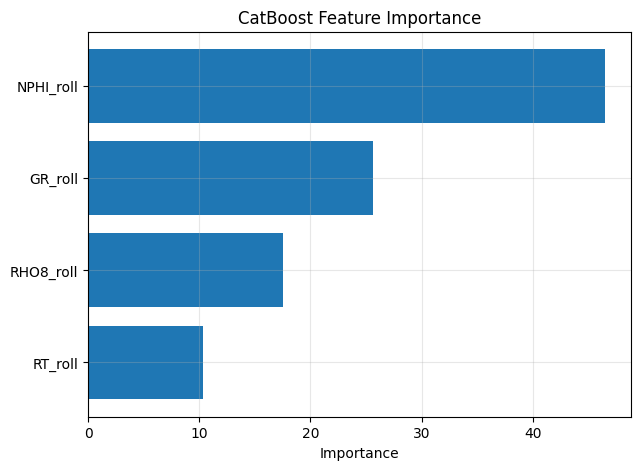

In [ ]:
plt.figure(figsize=(7,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.grid(alpha=0.3)

plt.show()

#Blind Test on CHANDON-1 WELL


BLIND WELL PERFORMANCE
R2   : 0.9676
MAE  : 0.3895
RMSE : 0.4504


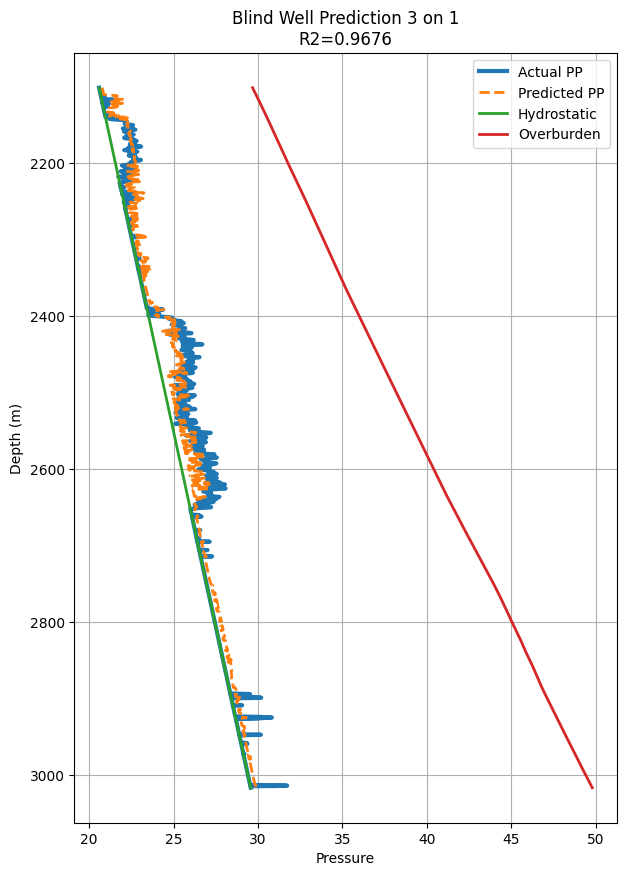

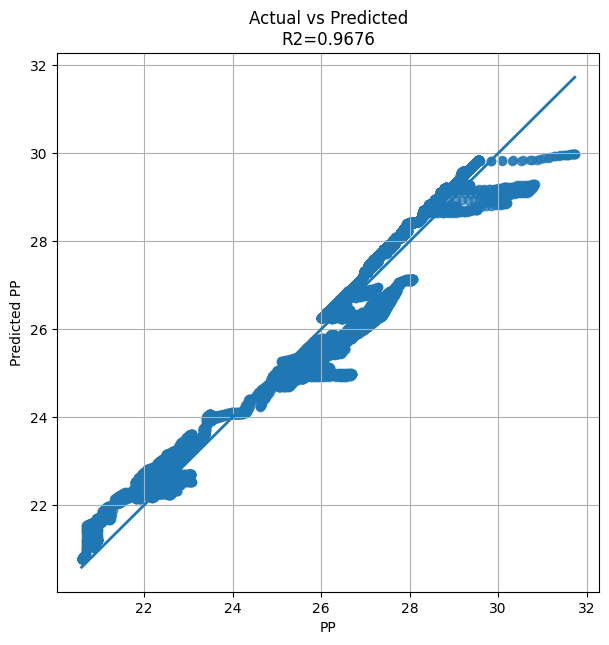


Saved : blind_well_predictions 3 on 1.csv


In [ ]:
# =========================================================
# BLIND WELL PORE PRESSURE PREDICTION
# WITHOUT CALIBRATION
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install catboost

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# =========================================================
# LOAD TRAINING DATA
# =========================================================

train_df = pd.read_csv(
    "/content/TEST_updated.csv"
)

# =========================================================
# TRAINING DEPTH FILTER
# =========================================================

train_df = train_df[
    (train_df["DEPTH"] >= 2117) &
    (train_df["DEPTH"] <= 2900)
].copy()

train_df = train_df.sort_values(
    "DEPTH"
).reset_index(drop=True)

# =========================================================
# LITHOLOGY FLAGS
# =========================================================

# =========================================================
# TARGET
# =========================================================

train_df["PP_ratio"] = (
    train_df["Actual_PP"] /
    train_df["Phyd"]
)

# sandstone hydrostatic


# =========================================================
# ROLLING FEATURES
# =========================================================

window = 5

train_df["GR_roll"] = (
    train_df["GR"]
    .rolling(window, center=True)
    .mean()
)

train_df["NPHI_roll"] = (
    train_df["NPHI"]
    .rolling(window, center=True)
    .mean()
)

train_df["RHO8_roll"] = (
    train_df["RHO8"]
    .rolling(window, center=True)
    .mean()
)

train_df["RT_roll"] = (
    train_df["RT"]
    .rolling(window, center=True)
    .mean()
)




# =========================================================
# FEATURES
# =========================================================

features = [



    "RT_roll",



    "GR_roll",
    "NPHI_roll",
    "RHO8_roll",



]

# =========================================================
# REMOVE NaN
# =========================================================

train_df = train_df.replace(
    [np.inf, -np.inf],
    np.nan
)

train_df = train_df.dropna(
    subset=features + ["PP_ratio"]
)

# =========================================================
# TRAIN MODEL
# =========================================================

X_train = train_df[features]

y_train = train_df["PP_ratio"]

from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.001,
    depth=5,
    verbose=0
)

model.fit(
    X_train,
    y_train
)

# =========================================================
# LOAD BLIND TEST WELL
# =========================================================

blind_df = pd.read_csv(
    "/content/CHANDON_01_PP.csv"
)

blind_df = blind_df.sort_values(
    "DEPTH"
).reset_index(drop=True)

# =========================================================
# LITHOLOGY FLAGS
# =========================================================

# =========================================================
# ROLLING FEATURES
# =========================================================

blind_df["GR_roll"] = (
    blind_df["GR"]
    .rolling(window, center=True)
    .mean()
)

blind_df["NPHI_roll"] = (
    blind_df["NPHI"]
    .rolling(window, center=True)
    .mean()
)

blind_df["RHO8_roll"] = (
    blind_df["RHO8"]
    .rolling(window, center=True)
    .mean()
)
blind_df["RT_roll"] = (
    blind_df["RT"]
    .rolling(window, center=True)
    .mean()
)


# =========================================================
# REMOVE NaN
# =========================================================

blind_df = blind_df.replace(
    [np.inf, -np.inf],
    np.nan
)

blind_df = blind_df.dropna(
    subset=features
)

# =========================================================
# PREDICT BLIND WELL
# =========================================================

X_blind = blind_df[features]

pred_ratio = model.predict(
    X_blind
)

# =========================================================
# PHYSICS CONSTRAINTS
# =========================================================

# minimum hydrostatic

pred_ratio = np.maximum(
    pred_ratio,
    1.0
)

# =========================================================
# CONVERT TO PP
# =========================================================

pred_pp = (

    pred_ratio *

    blind_df["Phyd"].values
)

# sandstone hydrostatic


# maximum overburden



# =========================================================
# STORE PREDICTIONS
# =========================================================

blind_df["Predicted_PP"] = pred_pp

# =========================================================
# EVALUATION
# =========================================================

true_pp = blind_df["Pore_Pressure"].values

r2 = r2_score(
    true_pp,
    pred_pp
)

mae = mean_absolute_error(
    true_pp,
    pred_pp
)

rmse = np.sqrt(
    mean_squared_error(
        true_pp,
        pred_pp
    )
)

print("\n========================")
print("BLIND WELL PERFORMANCE")
print("========================")

print("R2   :", round(r2,4))

print("MAE  :", round(mae,4))

print("RMSE :", round(rmse,4))

# =========================================================
# PP VS DEPTH PLOT
# =========================================================

plt.figure(figsize=(7,10))

plt.plot(
    blind_df["Pore_Pressure"],
    blind_df["DEPTH"],
    linewidth=3,
    label="Actual PP"
)

plt.plot(
    pred_pp,
    blind_df["DEPTH"],
    linewidth=2,
    linestyle="--",
    label="Predicted PP"
)

plt.plot(
    blind_df["Phyd"],
    blind_df["DEPTH"],
    linewidth=2,
    label="Hydrostatic"
)

plt.plot(
    blind_df["SV"],
    blind_df["DEPTH"],
    linewidth=2,
    label="Overburden"
)

plt.gca().invert_yaxis()

plt.xlabel("Pressure")

plt.ylabel("Depth (m)")

plt.title(
    f"Blind Well Prediction 3 on 1\nR2={r2:.4f}"
)

plt.legend()

plt.grid()

plt.show()

# =========================================================
# CROSSPLOT
# =========================================================

plt.figure(figsize=(7,7))

plt.scatter(
    true_pp,
    pred_pp,
    alpha=0.7
)

min_val = min(
    true_pp.min(),
    pred_pp.min()
)

max_val = max(
    true_pp.max(),
    pred_pp.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linewidth=2
)

plt.xlabel("PP")

plt.ylabel("Predicted PP")

plt.title(
    f"Actual vs Predicted\nR2={r2:.4f}"
)

plt.grid()

plt.show()

# =========================================================
# SAVE RESULTS
# =========================================================

blind_df.to_csv(
    "blind_well_predictions 3 on 1.csv",
    index=False
)

print("\nSaved : blind_well_predictions 3 on 1.csv")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# get importance
importances = model.get_feature_importance()

# create dataframe for sorting
feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

feat_imp = feat_imp.sort_values("Importance", ascending=True)

# plot
plt.figure(figsize=(6,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])

plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.grid(alpha=0.3)

plt.show()

#Blind Test on CHANDON-2 WELL